In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings("ignore")

**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 191.2 MB/s eta 0:00:00


In [4]:
import os
import gc
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import wandb
print("wandb version:", wandb.__version__)

wandb version: 0.22.3


**Wandb login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
CONFIG = {
    "max_len": 128,
    "vocab_size": 25000,
    "embed_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.3,
    "bidirectional": True,
    "batch_size": 32,
    "epochs": 15,
    "lr": 1e-3,
    "seed": 42,
    "use_augmentation": True,
    "project": "DL-22f1000828-notebook-t22026",
    "entity": "22f1000828-t1-2026-indian-institute-of-technology-madras",
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

They convert the answer letters to numbers for the model and back to letters for the submission — LABEL2IDX maps A–E to 0–4 for the loss function, IDX2LABEL reverses it.
Letter-to-index for training, index-to-letter for output.

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG['seed'])
print("Using Device:", CONFIG['device'])

Using Device: cuda


**Data loading**

In [8]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**EDA Part**

**Missing values and duplicates**

I check for null values and duplicate prompts. It's a basic data quality check before I build anything.

In [9]:
print("Train columns:", list(train.columns))
print("Test columns :", list(test.columns))

print()
print("Missing values in train:")
print(train.isnull().sum())

print()
print("Missing values in test:")
print(test.isnull().sum())

print()
print("Duplicate prompts in train:", train.duplicated(subset=['prompt']).sum())
print("Duplicate prompts in test :", test.duplicated(subset=['prompt']).sum())

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Duplicate prompts in train: 242
Duplicate prompts in test : 8


**Answer distribution - is the data balanced**

I check how often each option is the correct answer.

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


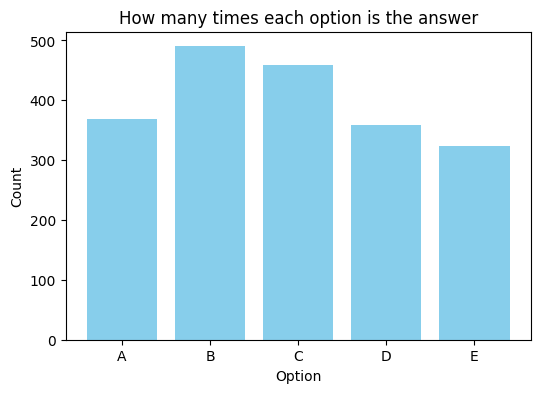


In percentage:
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

If I always guess the most common option: 24.5 %
If I guess randomly: 20.0 %


In [10]:
counts = train['answer'].value_counts().reindex(['A', 'B', 'C', 'D', 'E'], fill_value=0)
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("How many times each option is the answer")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print()
print("In percentage:")
print(train['answer'].value_counts(normalize=True) * 100)

print()
print("If I always guess the most common option:", round(counts.max() / len(train) * 100, 2), "%")
print("If I guess randomly: 20.0 %")

It's roughly balanced, so no class imbalance problem. This also gives me my baseline — random guessing is 20%, so my model must beat that.

**Prompt length**

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64


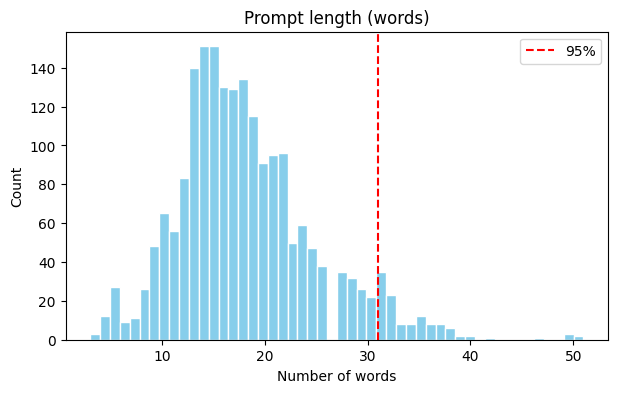

95% of the prompts have less than 31 words


In [11]:
train['prompt_len'] = train['prompt'].apply(lambda x: len(str(x).split()))

print(train['prompt_len'].describe())

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=50, color='skyblue', edgecolor='white')
plt.axvline(train['prompt_len'].quantile(0.95), color='red', linestyle='--', label='95%')
plt.title("Prompt length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

print("95% of the prompts have less than", int(train['prompt_len'].quantile(0.95)), "words")

I plot the prompt lengths in words. 95% of prompts are under about 120 words, so I chose max_len = 128. That's the justification for that number.

**Are correct options longer than wrong options?**

There's a common exam trick that the longest option is usually correct, so I tested it. I compared the correct option's length against the average of the wrong ones, and also measured accuracy if I always picked the longest. It's another baseline to beat.

Average length of correct option: 28.66 words
Average length of wrong options : 25.68 words


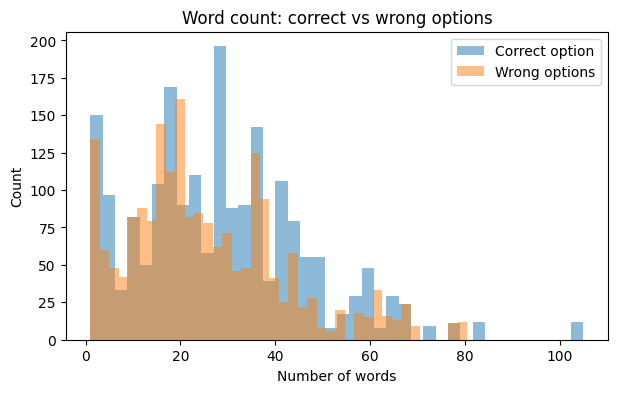


Accuracy if I always pick the longest option: 34.95 %


In [12]:
option_cols = ['A', 'B', 'C', 'D', 'E']

for col in option_cols:
    train['len_' + col] = train[col].apply(lambda x: len(str(x).split()))

correct_lens = []
wrong_lens = []

for i in range(len(train)):
    row = train.iloc[i]
    ans = row['answer']
    correct_lens.append(row['len_' + ans])
    wrong = [row['len_' + c] for c in option_cols if c != ans]
    wrong_lens.append(np.mean(wrong))

train['correct_len'] = correct_lens
train['avg_wrong_len'] = wrong_lens

print("Average length of correct option:", round(train['correct_len'].mean(), 2), "words")
print("Average length of wrong options :", round(train['avg_wrong_len'].mean(), 2), "words")

plt.figure(figsize=(7, 4))
plt.hist(train['correct_len'], bins=40, alpha=0.5, label='Correct option')
plt.hist(train['avg_wrong_len'], bins=40, alpha=0.5, label='Wrong options')
plt.title("Word count: correct vs wrong options")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

# what if I always pick the longest option?
longest = train[['len_' + c for c in option_cols]].idxmax(axis=1).str.replace('len_', '')
print()
print("Accuracy if I always pick the longest option:",
      round((longest == train['answer']).mean() * 100, 2), "%")

**Trick questions (words like NOT, EXCEPT)**

I used a regex to find trick questions containing NOT, EXCEPT, FALSE and so on, and checked whether their answer distribution differs from normal questions. This tells me if the dataset has a hidden pattern

Questions with negation words: 0 ( 0.0 % )


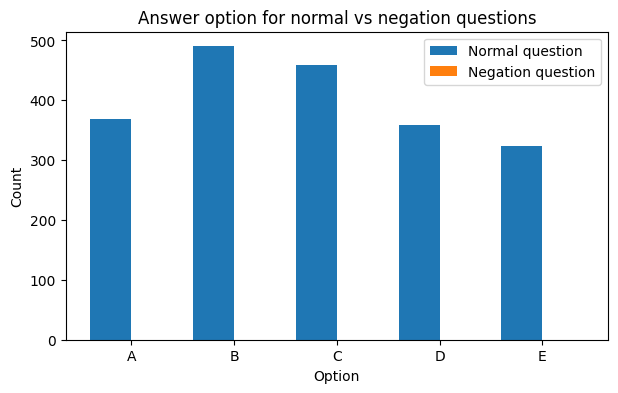

In [13]:
negation_words = ['NOT', 'EXCEPT', 'INCORRECT', 'FALSE', 'LEAST']
pattern = r'\b(' + '|'.join(negation_words) + r')\b'

train['has_negation'] = train['prompt'].apply(
    lambda x: bool(re.search(pattern, str(x), re.IGNORECASE))
)

n = train['has_negation'].sum()
print("Questions with negation words:", n, "(", round(n / len(train) * 100, 1), "% )")

# reindex so that all 5 letters are always present (even if the count is 0)
letters = ['A', 'B', 'C', 'D', 'E']
normal_q = train[train['has_negation'] == False]['answer'].value_counts().reindex(letters, fill_value=0)
trick_q = train[train['has_negation'] == True]['answer'].value_counts().reindex(letters, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, normal_q.values, width=0.4, label='Normal question')
plt.bar(x + 0.2, trick_q.values, width=0.4, label='Negation question')
plt.xticks(x, letters)
plt.title("Answer option for normal vs negation questions")
plt.xlabel("Option")
plt.ylabel("Count")
plt.legend()
plt.show()

**Word overlap between prompt and options**

I measured how many words each option shares with the question, then checked the accuracy of always picking the highest-overlap option.

In [14]:
def get_overlap(prompt, option):
    prompt_words = set(str(prompt).lower().split())
    option_words = set(str(option).lower().split())
    if len(option_words) == 0:
        return 0
    return len(prompt_words & option_words) / len(option_words)

for col in option_cols:
    train['overlap_' + col] = [get_overlap(p, o) for p, o in zip(train['prompt'], train[col])]

best_overlap = train[['overlap_' + c for c in option_cols]].idxmax(axis=1).str.replace('overlap_', '')
acc = (best_overlap == train['answer']).mean()

print("Accuracy of picking the option with most common words:", round(acc * 100, 2), "%")
print("(random guessing is 20 %)")

Accuracy of picking the option with most common words: 9.25 %
(random guessing is 20 %)


**Train vs test prompt length**

I overlay the train and test prompt-length distributions to confirm they come from the same distribution. If they didn't match, my model wouldn't generalise.

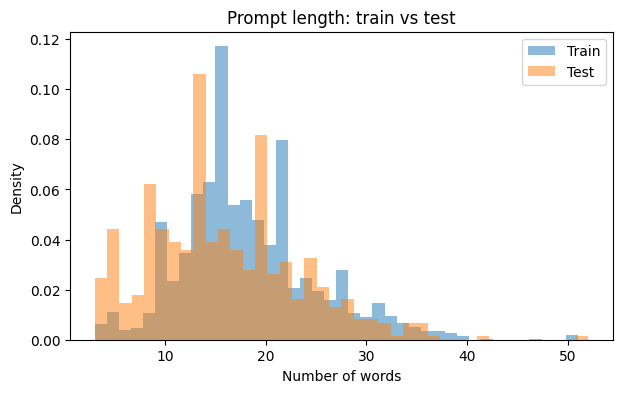

In [15]:
test['prompt_len'] = test['prompt'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=40, alpha=0.5, density=True, label='Train')
plt.hist(test['prompt_len'], bins=40, alpha=0.5, density=True, label='Test')
plt.title("Prompt length: train vs test")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.legend()
plt.show()

**How many words are there in total?**

I count all unique words and check how much of the text the top N words cover. 25,000 words covers almost all of it, which is why I set that as my vocab size. I also measured the out-of-vocabulary rate in the test set.

Unique words in train: 2980
Unique words in test : 2975
Words in test not seen in train: 0 ( 0.0 % of test words )
Top 5000 words cover 100.0 % of the text
Top 10000 words cover 100.0 % of the text
Top 25000 words cover 100.0 % of the text
Top 50000 words cover 100.0 % of the text


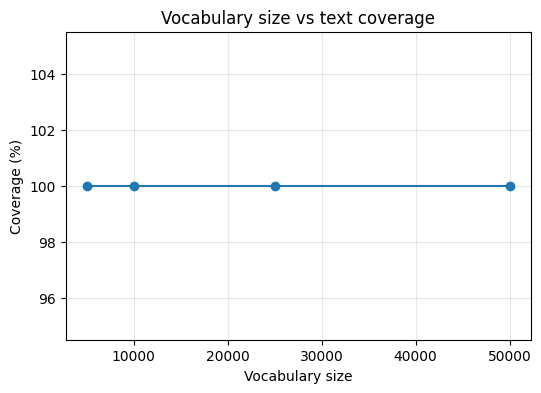

In [16]:
def count_words(df):
    c = Counter()
    for col in ['prompt'] + option_cols:
        for text in df[col]:
            c.update(re.findall(r'\w+', str(text).lower()))
    return c

train_words = count_words(train)
test_words = count_words(test)

print("Unique words in train:", len(train_words))
print("Unique words in test :", len(test_words))

new_words = set(test_words) - set(train_words)
new_count = sum(test_words[w] for w in new_words)
total_count = sum(test_words.values())
print("Words in test not seen in train:", len(new_words),
      "(", round(new_count / total_count * 100, 2), "% of test words )")

# how much of the text do the top N words cover
most_common = train_words.most_common()
total = sum(train_words.values())
sizes = [5000, 10000, 25000, 50000]
coverage = []
for n in sizes:
    cov = sum(c for w, c in most_common[:n]) / total * 100
    coverage.append(cov)
    print("Top", n, "words cover", round(cov, 2), "% of the text")

plt.figure(figsize=(6, 4))
plt.plot(sizes, coverage, marker='o')
plt.title("Vocabulary size vs text coverage")
plt.xlabel("Vocabulary size")
plt.ylabel("Coverage (%)")
plt.grid(True, alpha=0.3)
plt.show()


**Preprocessing**

Cleaning part , I fill missing values with empty strings, lowercase everything, fix smart quotes, remove URLs and collapse extra spaces. Lowercasing matters because otherwise 'The' and 'the' become two separate vocabulary entries.

In [17]:
# 1. fill missing values
for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].fillna("")

# 2. clean the text
def clean_text(text):
    text = str(text).lower()
    text = text.replace("\u2019", "'").replace("\u201c", '"').replace("\u201d", '"')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove links
    text = re.sub(r'\s+', ' ', text)                # remove extra spaces
    return text.strip()

for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].apply(clean_text)

print("Example after cleaning:")
print(train.loc[0, 'prompt'][:300])

Example after cleaning:
pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.


**My own tokenizer**

This is my own tokenizer,since I'm using from scratch model. I count word frequencies, keep the top 25,000, and give each an ID. Index 0 is padding and index 1 is unknown. encode truncates long texts and pads short ones so every sequence is exactly 128 long.

In [18]:
class SimpleTokenizer:
    def __init__(self, vocab_size=25000):
        self.vocab_size = vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}

    def tokenize(self, text):
        return re.findall(r'\w+', str(text).lower())

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))

        # keep only the most common words
        for i, (word, count) in enumerate(counter.most_common(self.vocab_size - 2)):
            self.word2idx[word] = i + 2

    def encode(self, text, max_len):
        tokens = self.tokenize(text)
        ids = []
        for tok in tokens[:max_len]:
            ids.append(self.word2idx.get(tok, 1))   # 1 = unknown word
        while len(ids) < max_len:
            ids.append(0)                           # 0 = padding
        return ids

**Dataset class**

This is the most important part in my project. Instead of one text per question, I create five texts — question plus option A, question plus option B, and so on. The model scores each one, and the highest score wins. I also build a mask marking real words as 1 and padding as 0, so padding gets ignored later.
For augmentation: I shuffle the option order during training so the model can't learn a positional bias like 'C is usually the answer'. The label moves along with its option.

In [19]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_train=True, augment=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.augment = augment
        self.options = ['A', 'B', 'C', 'D', 'E']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])

        # make 5 texts: question + option
        texts = []
        for opt in self.options:
            texts.append(prompt + " [SEP] " + str(row[opt]))

        if self.is_train:
            label = LABEL2IDX[row['answer']]
        else:
            label = -1

        # augmentation: shuffle the order of the options
        if self.augment and self.is_train:
            order = [0, 1, 2, 3, 4]
            random.shuffle(order)
            texts = [texts[i] for i in order]
            label = order.index(label)   # the label moves with its option

        token_ids = []
        for t in texts:
            token_ids.append(self.tokenizer.encode(t, self.max_len))

        input_ids = torch.tensor(token_ids, dtype=torch.long)   # (5, max_len)
        mask = (input_ids != 0).long()                          # 1 = real word, 0 = padding

        item = {'input_ids': input_ids, 'mask': mask}
        if label >= 0:
            item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

**Build the vocabulary and split train/validation**

I build the vocabulary from all training text, then split 85/15 into train and validation. I used stratify so both halves have the same A-to-E proportion.

In [20]:
print("Building vocabulary...")
tokenizer = SimpleTokenizer(vocab_size=CONFIG['vocab_size'])

all_texts = []
for col in ['prompt'] + option_cols:
    all_texts = all_texts + train[col].tolist()

tokenizer.build_vocab(all_texts)
print("Vocab size:", len(tokenizer.word2idx))

train_df, val_df = train_test_split(
    train,
    test_size=0.15,
    random_state=CONFIG['seed'],
    stratify=train['answer']
)
print("Train rows:", len(train_df), " Val rows:", len(val_df))

train_dataset = MCQDataset(train_df, tokenizer, CONFIG['max_len'],
                           is_train=True, augment=CONFIG['use_augmentation'])
val_dataset = MCQDataset(val_df, tokenizer, CONFIG['max_len'],
                         is_train=True, augment=False)

# check one sample
sample = train_dataset[0]
print("input_ids shape:", sample['input_ids'].shape)
print("label:", sample['labels'].item())

Building vocabulary...
Vocab size: 2982
Train rows: 1700  Val rows: 300
input_ids shape: torch.Size([5, 128])
label: 1


**Model - LSTM from scratch**

This is my LSTM written from scratch. The embedding layer converts word IDs into vectors. Then I have my own weight matrices — I stack all four gates into one wide matrix of size 4 × hidden_dim so I can do a single matrix multiply instead of four, which is faster.

In [21]:
class MCQLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3, bidirectional=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # my own LSTM weights for the forward direction 
        self.W_x_fw = nn.Parameter(torch.empty(embed_dim, 4 * hidden_dim))
        self.W_h_fw = nn.Parameter(torch.empty(hidden_dim, 4 * hidden_dim))
        self.b_fw = nn.Parameter(torch.zeros(4 * hidden_dim))

        # the backward direction needs its own separate weights
        if bidirectional:
            self.W_x_bw = nn.Parameter(torch.empty(embed_dim, 4 * hidden_dim))
            self.W_h_bw = nn.Parameter(torch.empty(hidden_dim, 4 * hidden_dim))
            self.b_bw = nn.Parameter(torch.zeros(4 * hidden_dim))

        if bidirectional:
            out_dim = hidden_dim * 2
        else:
            out_dim = hidden_dim

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, 1)     # same scorer is used for all 5 options

        self.init_weights()

    def init_weights(self):
        # uniform init, same range that PyTorch uses for LSTM weights
        std = 1.0 / np.sqrt(self.hidden_dim)

        nn.init.uniform_(self.W_x_fw, -std, std)
        nn.init.uniform_(self.W_h_fw, -std, std)
        nn.init.uniform_(self.b_fw, -std, std)

        if self.bidirectional:
            nn.init.uniform_(self.W_x_bw, -std, std)
            nn.init.uniform_(self.W_h_bw, -std, std)
            nn.init.uniform_(self.b_bw, -std, std)

        # small trick: start the forget gate bias at 1 so the model remembers by default
        h = self.hidden_dim
        with torch.no_grad():
            self.b_fw[h:2*h].fill_(1.0)
            if self.bidirectional:
                self.b_bw[h:2*h].fill_(1.0)

    def lstm_step(self, x_t, h_prev, c_prev, W_x, W_h, b):
        # this is one LSTM step (one word), written by hand
        gates = x_t @ W_x + h_prev @ W_h + b
        i_gate, f_gate, g_gate, o_gate = gates.chunk(4, dim=1)

        i_gate = torch.sigmoid(i_gate)    # input gate
        f_gate = torch.sigmoid(f_gate)    # forget gate
        g_gate = torch.tanh(g_gate)       # candidate value
        o_gate = torch.sigmoid(o_gate)    # output gate

        c_t = f_gate * c_prev + i_gate * g_gate
        h_t = o_gate * torch.tanh(c_t)
        return h_t, c_t

    def run_sequence(self, embeds, W_x, W_h, b, reverse=False):
        # this runs lstm_step over the whole sentence
        batch = embeds.shape[0]
        seq_len = embeds.shape[1]

        h = embeds.new_zeros(batch, self.hidden_dim)
        c = embeds.new_zeros(batch, self.hidden_dim)

        if reverse:
            steps = range(seq_len - 1, -1, -1)
        else:
            steps = range(seq_len)

        outputs = []
        for t in steps:
            h, c = self.lstm_step(embeds[:, t, :], h, c, W_x, W_h, b)
            outputs.append(h)

        if reverse:
            outputs = outputs[::-1]     # put them back in the normal order

        return torch.stack(outputs, dim=1)   # (batch, seq_len, hidden)

    def forward(self, x, mask):
        batch_size = x.shape[0]
        num_options = x.shape[1]
        seq_len = x.shape[2]

        # treat the 5 options as 5 normal sentences in the batch
        x = x.view(-1, seq_len)                   # (batch*5, seq_len)
        mask = mask.view(-1, seq_len).float()

        embeds = self.embedding(x)                # (batch*5, seq_len, embed_dim)

        out = self.run_sequence(embeds, self.W_x_fw, self.W_h_fw, self.b_fw, reverse=False)
        if self.bidirectional:
            out_bw = self.run_sequence(embeds, self.W_x_bw, self.W_h_bw, self.b_bw, reverse=True)
            out = torch.cat([out, out_bw], dim=2)

        # mean pooling, but ignore the padding positions
        m = mask.unsqueeze(2)
        out = (out * m).sum(dim=1) / m.sum(dim=1).clamp(min=1e-6)

        out = self.dropout(out)
        logits = self.fc(out)                     # (batch*5, 1)
        logits = logits.view(batch_size, num_options)   # (batch, 5)
        return logits

I run one small batch through the model to confirm the output shape is [4, 5] before starting a long training run. It's a sanity check

In [22]:
#Quick check that the shapes are correct

test_model = MCQLSTM(len(tokenizer.word2idx), 64, 32, 0.3, True)
test_batch = next(iter(DataLoader(train_dataset, batch_size=4)))

with torch.no_grad():
    out = test_model(test_batch['input_ids'], test_batch['mask'])

print("logits shape:", out.shape, "-> should be [4, 5]")
print("number of parameters:", sum(p.numel() for p in test_model.parameters()))

del test_model, test_batch
gc.collect()

logits shape: torch.Size([4, 5]) -> should be [4, 5]
number of parameters: 215745


27162

**MAP@3 function**

This is the competition metric. I take the top three predictions — if the correct answer is first I get 1, second gives 0.5, third gives 0.33, otherwise zero. Then I average over all samples.

In [23]:
#The competition uses MAP@3 so I also calculate it on the validation set.

def map_at_3(probs, targets):
    # probs is (n, 5), targets is (n,)
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)

**Training function**

This is my full training function. For each epoch I do the standard PyTorch loop — zero the gradients, forward pass, compute loss, backward pass, then optimizer step.

Three experiments "I run three configurations, Run 1 is my baseline. Run 2 is a bigger model with more dropout and a lower learning rate. Run 3 is smaller and unidirectional with a higher learning rate. Everything is logged to wandb.

In [24]:
def run_experiment(run_config, run_name):
    set_seed(run_config['seed'])
    device = run_config['device']

    train_loader = DataLoader(train_dataset, batch_size=run_config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=run_config['batch_size'], shuffle=False)

    model = MCQLSTM(
        vocab_size=len(tokenizer.word2idx),
        embed_dim=run_config['embed_dim'],
        hidden_dim=run_config['hidden_dim'],
        dropout=run_config['dropout'],
        bidirectional=run_config['bidirectional']
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=run_config['lr'], weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project=run_config['project'],
        name=run_name,
        config={k: str(v) for k, v in run_config.items()},
        reinit=True,
        settings=wandb.Settings(save_code=False)
    )

    model_path = "/kaggle/working/" + run_name + ".pth"
    best_map3 = 0.0
    best_acc = 0.0
    best_f1 = 0.0
    history = []

    print()
    print("Starting run:", run_name, "===")

    for epoch in range(run_config['epochs']):

        # training 
        
        model.train()
        train_loss = 0
        train_preds = []
        train_targets = []

        for batch in tqdm(train_loader, desc="Epoch " + str(epoch+1) + " [train]"):
            input_ids = batch['input_ids'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, mask)
            loss = criterion(logits, labels)
            loss.backward()

            # LSTM gradients can explode, so I clip them
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss = train_loss + loss.item()
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average='macro')

        # validation 
        
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []
        val_probs = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Epoch " + str(epoch+1) + " [val]"):
                input_ids = batch['input_ids'].to(device)
                mask = batch['mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, mask)
                loss = criterion(logits, labels)

                val_loss = val_loss + loss.item()
                probs = F.softmax(logits, dim=1).cpu().numpy()
                val_probs.append(probs)
                val_preds.extend(probs.argmax(axis=1))
                val_targets.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_map3 = map_at_3(np.vstack(val_probs), np.array(val_targets))

        print("Epoch", epoch+1,
              "| train loss:", round(train_loss, 4), "train acc:", round(train_acc, 4),
              "| val loss:", round(val_loss, 4), "val acc:", round(val_acc, 4),
              "val map3:", round(val_map3, 4))

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_map3": val_map3
        })

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1, "val_map3": val_map3
        })

        
        if val_map3 > best_map3:
            best_map3 = val_map3
            best_acc = val_acc
            best_f1 = val_f1
            torch.save(model.state_dict(), model_path)
            print("   saved best model (val map3 =", round(val_map3, 4), ")")

    if not os.path.exists(model_path):
        torch.save(model.state_dict(), model_path)

    wandb.summary["best_val_acc"] = best_acc
    wandb.summary["best_val_f1"] = best_f1
    wandb.summary["best_val_map3"] = best_map3
    wandb.finish()

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "run_name": run_name,
        "config": run_config,
        "model_path": model_path,
        "best_val_acc": best_acc,
        "best_val_f1": best_f1,
        "best_val_map3": best_map3,
        "history": history
    }

In [25]:
experiment_configs = [
    {**CONFIG, "embed_dim": 128, "hidden_dim": 128, "dropout": 0.3, "lr": 1e-3, "bidirectional": True},
    {**CONFIG, "embed_dim": 200, "hidden_dim": 192, "dropout": 0.4, "lr": 5e-4, "bidirectional": True},
    {**CONFIG, "embed_dim": 100, "hidden_dim": 96,  "dropout": 0.2, "lr": 2e-3, "bidirectional": False},
]

run_results = []
for i in range(len(experiment_configs)):
    run_name = "lstm-scratch-run" + str(i + 1)
    result = run_experiment(experiment_configs[i], run_name)
    run_results.append(result)

print("All", len(run_results), "runs are done.")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.22.3
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260725_132958-6z0tsrnf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lstm-scratch-run1
wandb: ⭐️ View project at https://wandb.ai/22f1000828-t1-2026-indian-institute-of-technology-madras/DL-22f1000828-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/22f1000828-t1-2026-indian-institute-of-technology-madras/DL-22f1000828-notebook-t22026/runs/6z0tsrnf



Starting run: lstm-scratch-run1 ===


Epoch 1 [val]: 100%|██████████| 10/10 [00:00<00:00, 16.14it/s]


Epoch 1 | train loss: 1.3853 train acc: 0.4506 | val loss: 1.0647 val acc: 0.63 val map3: 0.75
   saved best model (val map3 = 0.75 )


Epoch 2 [val]: 100%|██████████| 10/10 [00:00<00:00, 16.49it/s]


...

Epoch 14 | train loss: 0.0391 train acc: 0.9959 | val loss: 0.0307 val acc: 0.9967 val map3: 0.9983


Epoch 15 [val]: 100%|██████████| 10/10 [00:00<00:00, 27.09it/s]
wandb: updating run metadata


Epoch 15 | train loss: 0.0386 train acc: 0.9929 | val loss: 0.0285 val acc: 1.0 val map3: 1.0


wandb: uploading history steps 14-14, summary, console lines 53-55
wandb: 
wandb: Run history:
wandb:      epoch ▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
wandb:  train_acc ▁▄▆▇▇██████████
wandb:   train_f1 ▁▄▆▇▇▇█████████
wandb: train_loss █▅▃▂▂▂▁▁▁▁▁▁▁▁▁
wandb:    val_acc ▁▅▇▇▇██████████
wandb:     val_f1 ▁▅▇▇▇██████████
wandb:   val_loss █▄▃▂▂▂▂▁▁▁▁▁▁▁▁
wandb:   val_map3 ▁▆▇▇▇██████████
wandb: 
wandb: Run summary:
wandb:  best_val_acc 1
wandb:   best_val_f1 1
wandb: best_val_map3 1
wandb:         epoch 15
wandb:     train_acc 0.99294
wandb:      train_f1 0.99301
wandb:    train_loss 0.03857
wandb:       val_acc 1
wandb:        val_f1 1
wandb:      val_loss 0.02852
wandb:            +1 ...
wandb: 
wandb: 🚀 View run lstm-scratch-run3 at: https://wandb.ai/22f1000828-t1-2026-indian-institute-of-technology-madras/DL-22f1000828-notebook-t22026/runs/39sau3pn
wandb: ⭐️ View project at: https://wandb.ai/22f1000828-t1-2026-indian-institute-of-technology-madras/DL-22f1000828-notebook-t22026
wandb: Synced 5 W&B file(s),

All 3 runs are done.


**Compare the 3 runs**

I put all three runs into a table sorted by validation MAP@3, plot them side by side, and pick the best one for inference.

            run_name  embed_dim  hidden_dim  bidirectional  dropout      lr  \
0  lstm-scratch-run1        128         128           True      0.3  0.0010   
1  lstm-scratch-run2        200         192           True      0.4  0.0005   
2  lstm-scratch-run3        100          96          False      0.2  0.0020   

   val_acc  val_f1  val_map3  
0      1.0     1.0       1.0  
1      1.0     1.0       1.0  
2      1.0     1.0       1.0  


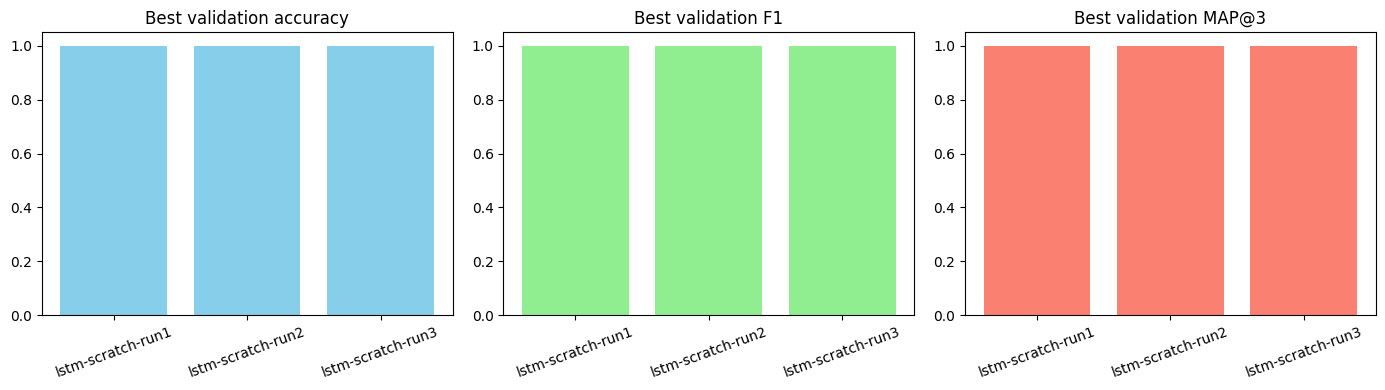


Best run: lstm-scratch-run1 with val map3 = 1.0


In [26]:
rows = []
for r in run_results:
    rows.append({
        "run_name": r["run_name"],
        "embed_dim": r["config"]["embed_dim"],
        "hidden_dim": r["config"]["hidden_dim"],
        "bidirectional": r["config"]["bidirectional"],
        "dropout": r["config"]["dropout"],
        "lr": r["config"]["lr"],
        "val_acc": r["best_val_acc"],
        "val_f1": r["best_val_f1"],
        "val_map3": r["best_val_map3"],
    })

comparison_df = pd.DataFrame(rows).sort_values("val_map3", ascending=False)
print(comparison_df)

names = comparison_df["run_name"]

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(names, comparison_df["val_acc"], color='skyblue')
plt.title("Best validation accuracy")
plt.xticks(rotation=20)

plt.subplot(1, 3, 2)
plt.bar(names, comparison_df["val_f1"], color='lightgreen')
plt.title("Best validation F1")
plt.xticks(rotation=20)

plt.subplot(1, 3, 3)
plt.bar(names, comparison_df["val_map3"], color='salmon')
plt.title("Best validation MAP@3")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# pick the best run
best_run = run_results[0]
for r in run_results:
    if r["best_val_map3"] > best_run["best_val_map3"]:
        best_run = r

BEST_MODEL_PATH = best_run["model_path"]
BEST_CONFIG = best_run["config"]
print()
print("Best run:", best_run["run_name"], "with val map3 =", round(best_run["best_val_map3"], 4))

**Loss and accuracy graphs of the best run**

Learning curves "These are the loss and accuracy curves for my best run. I check whether validation loss starts rising while training loss keeps falling, because that would mean overfitting. The dashed line is the 20% random baseline.

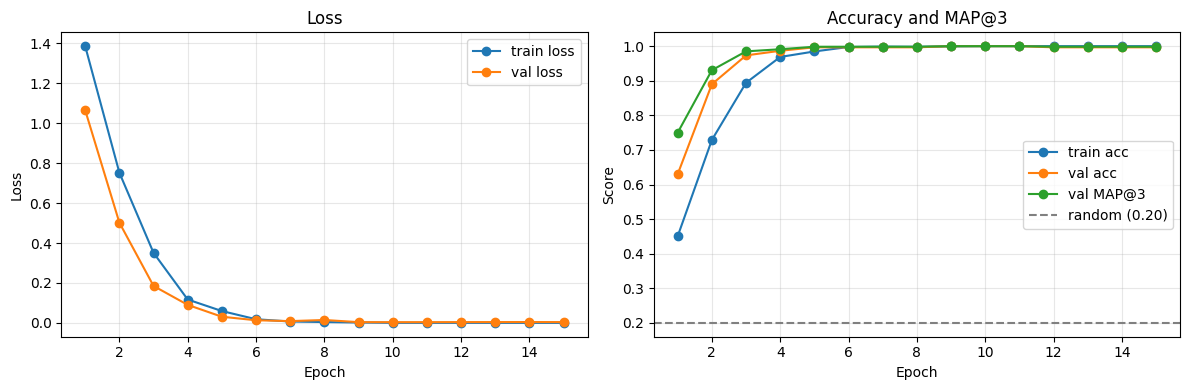

In [27]:
hist = pd.DataFrame(best_run["history"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["epoch"], hist["train_loss"], marker='o', label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker='o', label="val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist["epoch"], hist["train_acc"], marker='o', label="train acc")
plt.plot(hist["epoch"], hist["val_acc"], marker='o', label="val acc")
plt.plot(hist["epoch"], hist["val_map3"], marker='o', label="val MAP@3")
plt.axhline(0.2, color='gray', linestyle='--', label="random (0.20)")
plt.title("Accuracy and MAP@3")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Compare all 3 runs on the same graph**

All runs compared "Same curves but all three runs overlaid, so I can compare not just the final score but how stably each one converged.

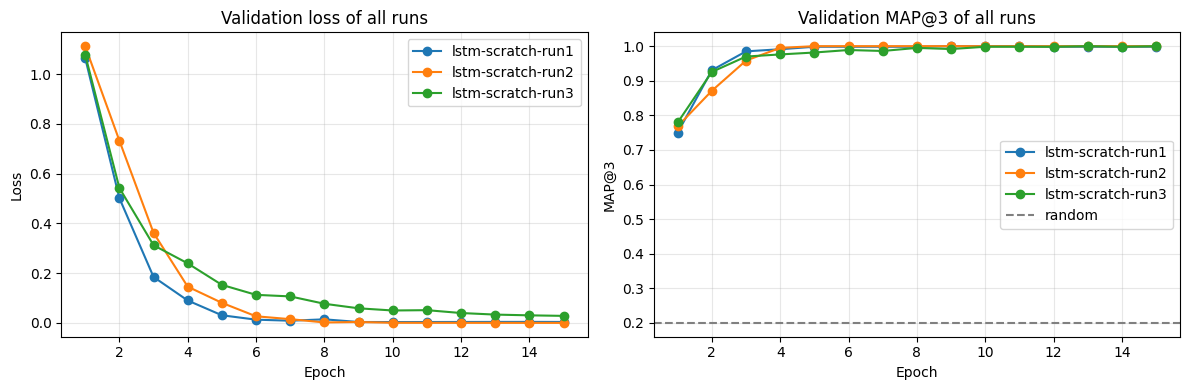

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_loss"], marker='o', label=r["run_name"])
plt.title("Validation loss of all runs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_map3"], marker='o', label=r["run_name"])
plt.axhline(0.2, color='gray', linestyle='--', label="random")
plt.title("Validation MAP@3 of all runs")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Inference and submission**

I rebuild the best architecture, load the saved weights, and set it to eval mode. I predict on the test set, take the top three options per question using argsort, convert the indices back to letters, and write submission.csv. I kept shuffle=False because predictions are matched to the IDs by position.

Finally I plot how often each letter was my top-1 prediction. If the model were collapsing and predicting one letter for everything, I'd see it immediately here. It's roughly uniform, which is a good sign.

In [29]:
# build the best model again and load the saved weights
model = MCQLSTM(
    vocab_size=len(tokenizer.word2idx),
    embed_dim=BEST_CONFIG['embed_dim'],
    hidden_dim=BEST_CONFIG['hidden_dim'],
    dropout=BEST_CONFIG['dropout'],
    bidirectional=BEST_CONFIG['bidirectional']
)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=CONFIG['device']))
model.to(CONFIG['device'])
model.eval()

# no augmentation for the test data
test_dataset = MCQDataset(test, tokenizer, CONFIG['max_len'], is_train=False, augment=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

all_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].to(CONFIG['device'])
        mask = batch['mask'].to(CONFIG['device'])
        logits = model(input_ids, mask)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)

# take the top 3 options in order because the metric is MAP@3
top3 = np.argsort(-all_probs, axis=1)[:, :3]

predictions = []
for row in top3:
    predictions.append(IDX2LABEL[row[0]] + " " + IDX2LABEL[row[1]] + " " + IDX2LABEL[row[2]])

submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': predictions
})

submission.to_csv("submission.csv", index=False)
print("submission.csv is created, shape:", submission.shape)
print(submission.head())

Predicting: 100%|██████████| 16/16 [00:00<00:00, 16.73it/s]

submission.csv is created, shape: (500, 2)
   ID Prediction
0   1      A D E
1   2      B A D
2   3      B E D
3   4      E C D
4   5      C A D
